### Replace `~/dataset/gas_config/gas.cu` with `GENGA:~/source/gas.cu`, recompile, then launch the gas disk configuration below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
import os
import sys
sys.path.append('../../src') # Adjust the path as needed
import accrediff as ad

In [2]:
# Build gas model
cfg = ad.Gas_ModelConfig(
    particle_mass_mearth=0.1, # Earth masses
    a0=0.5, # AU
    tau_decay_myr=1.0, # Myr
    a_alpha1=1.0,
    a_alpha2=0.5,
    Sigma0_cgs=1700, # g/cm^2
)
model = ad.Gas_build_model(cfg)
disk = model["disk"]
torque = model["torque"]
integrator = model["integrator"]
r_grid = np.linspace(0.1, 4.0, 800)
profile = torque.profile(r_grid, t_code=0.0)

## **gas disk profile** 
$$
\Sigma_{\rm g} = \Sigma_0 \left(\frac{r}{r_0}\right)^{-\beta(r)} \exp(-t/\tau)
$$
$$
\beta(r) \;=\; \beta_1 \ln(r/r_0) \;+\; \beta_2
$$
$$
\beta(1) = 1; \beta(2) = 0.5
$$


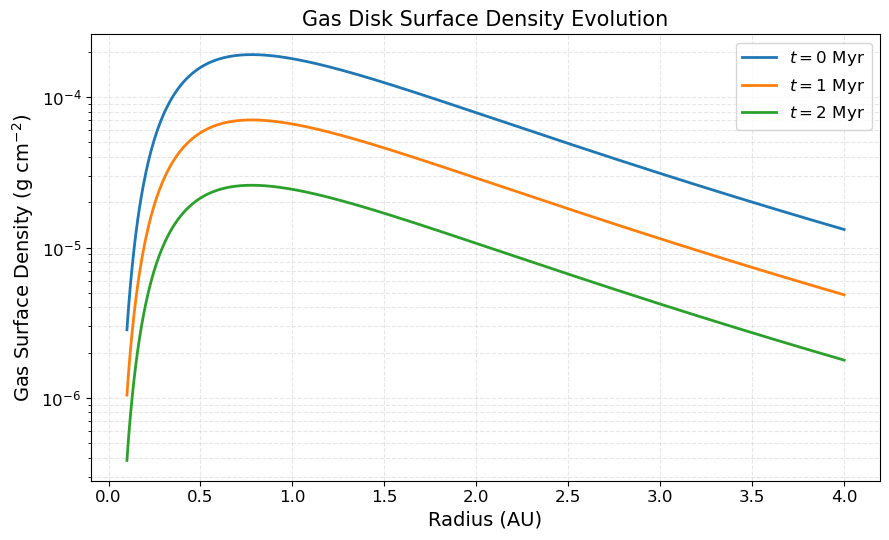

In [3]:
# Plot disk surface density profile at multiple epochs
units = disk.units
r = profile["r"]
# Define time snapshots: (t_myr, label)
time_snapshots = [
    (0.0,                        r'$t = 0$ Myr'),
    (units.myr_to_code(1.0),     r'$t = 1$ Myr'),
    (units.myr_to_code(2.0),     r'$t = 2$ Myr'),
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, ax = plt.subplots(figsize=(9, 5.5))
for (t_code, label), color in zip(time_snapshots, colors):
    sigma = disk.sigma(r, t_code=t_code)
    ax.plot(r, sigma, label=label, color=color, lw=2)

ax.set_yscale('log')

ax.set_xlabel('Radius (AU)', fontsize=14)
ax.set_ylabel(r'Gas Surface Density (g cm$^{-2}$)', fontsize=14)
ax.set_title('Gas Disk Surface Density Evolution', fontsize=15)
ax.legend(fontsize=12, frameon=True, framealpha=0.8)
ax.grid(True, which='both', alpha=0.3, ls='--')
ax.tick_params(labelsize=12)
fig.tight_layout()
plt.show()

### **Static Torque Formula** (Paardekooper+2010; 2011)

$$
\gamma \frac{\Gamma_{\rm tot}}{\Gamma_0}
= \underbrace{-(2.5 + 1.7\beta - 0.1\alpha)}_{\text{Lindblad torque}}
+ \underbrace{1.1\left(\frac{3}{2} - \alpha\right)}_{\text{barotropic corotation}}
+ \underbrace{\frac{7.9}{\gamma}\left[\beta - (\gamma-1)\alpha\right]}_{\text{entropy-related corotation}}
$$

where $\alpha = -d\ln\Sigma/d\ln r$, $\beta = -d\ln T/d\ln r$, $\gamma$ is the adiabatic index.

Torque zero: r = 0.9251 AU


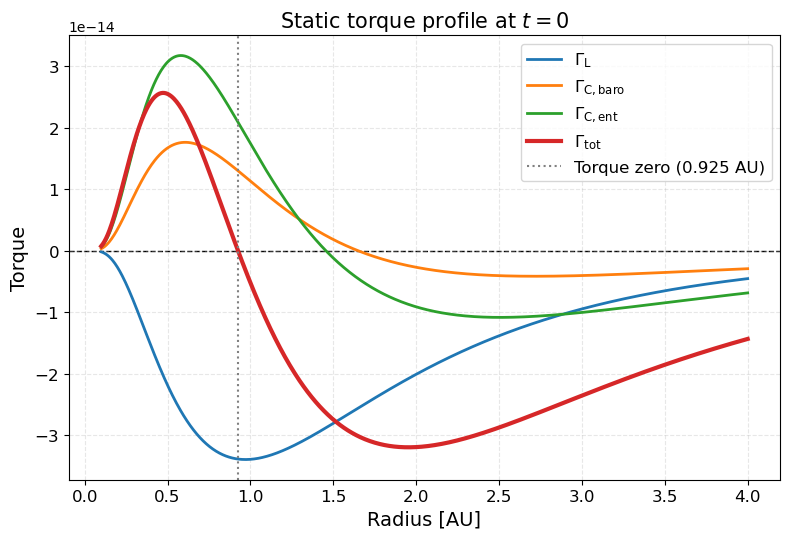

In [4]:
# =========================================================
#  Plot: static torque profile at t=0
# =========================================================
r         = profile["r"]
gamma_tot = profile["gamma_tot"]

# ----------------------------------------------------------
# 1. Find torque zero-crossings (linear interpolation at sign changes)
# ----------------------------------------------------------
sign_changes   = np.where(np.diff(np.sign(gamma_tot)))[0]
zero_crossings = []
for idx in sign_changes:
    r0, r1 = r[idx], r[idx + 1]
    g0, g1 = gamma_tot[idx], gamma_tot[idx + 1]
    r_zero = r0 - g0 * (r1 - r0) / (g1 - g0)   # linear interpolation
    zero_crossings.append(r_zero)
    print(f"Torque zero: r = {r_zero:.4f} AU")

# ----------------------------------------------------------
# 2. Define torque components and their plot styles
# ----------------------------------------------------------
components = [
    ("gamma_l",      r'$\Gamma_{\rm L}$',       '#1f77b4', 2, '-'),
    ("gamma_c_baro", r'$\Gamma_{\rm C,baro}$',  '#ff7f0e', 2, '-'),
    ("gamma_c_ent",  r'$\Gamma_{\rm C,ent}$',   '#2ca02c', 2, '-'),
    ("gamma_tot",    r'$\Gamma_{\rm tot}$',      '#d62728', 3, '-'),
]

# ----------------------------------------------------------
# 3. Plot
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))

# Draw each torque component curve
for key, label, color, lw, ls in components:
    ax.plot(r, profile[key], label=label, color=color, lw=lw, ls=ls)

# Reference zero line
ax.axhline(0.0, color='k', ls='--', lw=1, zorder=0)

# Mark torque zero-crossing positions
for r_zero in zero_crossings:
    ax.axvline(r_zero, color='gray', ls=':', lw=1.5,
               label=f'Torque zero ({r_zero:.3f} AU)')

# ----------------------------------------------------------
# 4. Axis labels, title, and legend
# ----------------------------------------------------------
ax.set_xlabel("Radius [AU]", fontsize=14)
ax.set_ylabel("Torque", fontsize=14)
ax.set_title(r"Static torque profile at $t=0$", fontsize=15)
ax.legend(fontsize=12, frameon=True, framealpha=0.8)
ax.grid(alpha=0.3, ls='--')
ax.tick_params(labelsize=12)

fig.tight_layout()
plt.show()

In [5]:
# build models and compare theory and simulation
model_params = [
    {"a0": 0.5, "label": "theory: 0.5 AU"},
    {"a0": 1.0, "label": "theory: 1.0 AU"},
    {"a0": 1.5, "label": "theory: 1.5 AU"},
]
results = []
for params in model_params:
    cfg = ad.Gas_ModelConfig(
        particle_mass_mearth=0.1, # Earth masses
        a0=params["a0"], # AU
        tau_decay_myr=1.0, # Myr
        a_alpha1=1.0,
        a_alpha2=0.5,
        t_max_myr=4.0, # Myr
    )
    model = ad.Gas_build_model(cfg)
    result = model['integrator'].integrate_full()
    result['label'] = params["label"]
    results.append(result)

In [6]:
# read simulation data
data_path = '../dataset/gas_config/'
df1 = pd.read_csv(data_path + 'hh_01.csv') # a0=0.5 AU, m=0.1 Mearth
df2 = pd.read_csv(data_path + 'hh_02.csv') # a0=1.0 AU, m=0.1 Mearth
df3 = pd.read_csv(data_path + 'hh_03.csv') # a0=1.5 AU, m=0.1 Mearth

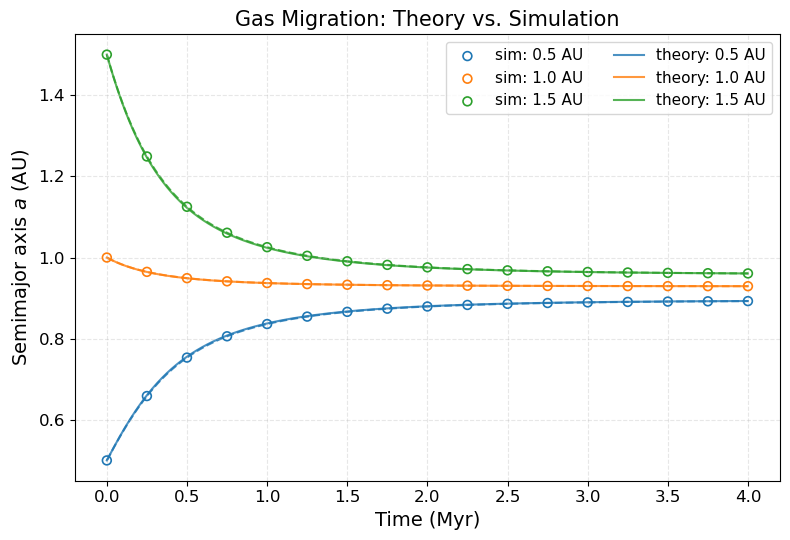

In [7]:
# =========================================================
#  Plot: semimajor axis vs time (simulation + theory)
# =========================================================
fig, ax = plt.subplots(figsize=(8, 5.5))

# ----------------------------------------------------------
# 1. Simulation data: dashed line + hollow scatter markers
# ----------------------------------------------------------
sim_configs = [
    (df1, 'sim: 0.5 AU', 'C0'),
    (df2, 'sim: 1.0 AU', 'C1'),
    (df3, 'sim: 1.5 AU', 'C2'),
]
step = 25   # scatter downsample interval

for df, label, color in sim_configs:
    ax.plot(df['Time'], df['a_1'],
            linestyle='--', linewidth=1.5,
            color=color, alpha=0.8, zorder=1)
    ax.scatter(df['Time'].iloc[::step], df['a_1'].iloc[::step],
               s=40, facecolors='none', edgecolors=color,
               linewidths=1.2, zorder=2, label=label)

# ----------------------------------------------------------
# 2. Theory: solid line
# ----------------------------------------------------------
for result, color in zip(results, ['C0', 'C1', 'C2']):
    ax.plot(result['t_myr'], result['a'],
            linestyle='-', linewidth=1.5,
            color=color, alpha=0.8, zorder=1, label=result['label'])

# ----------------------------------------------------------
# 3. Axis labels, title, and legend
# ----------------------------------------------------------
ax.set_xlabel('Time (Myr)', fontsize=14)
ax.set_ylabel('Semimajor axis $a$ (AU)', fontsize=14)
ax.set_title('Gas Migration: Theory vs. Simulation', fontsize=15)
ax.legend(fontsize=11, frameon=True, framealpha=0.8, ncol=2)
ax.grid(alpha=0.3, ls='--')
ax.tick_params(labelsize=12)

fig.tight_layout()
plt.show()